# FC DEQ-PC on FashionMNIST

Two-node implicit FC model trained via predictive coding.
Supports both **standard** and **equilibrium propagation** modes.

In [1]:
import io
import time
from contextlib import redirect_stderr, redirect_stdout

import jax
import jax.numpy as jnp
import jax.tree_util as jtu
import numpy as np
import optax
import matplotlib.pyplot as plt

import torch
import torchvision
import torchvision.transforms as transforms

import pcx as px
import pcx.nn as pxnn
import pcx.predictive_coding as pxc
import pcx.utils as pxu
import pcx.functional as pxf

from deq.models import FCMultiVodeDEQPCModel
from deq.training import (
    train_on_batch, eval_on_batch,
    train_on_batch_ep, eval_on_batch_ep,
    _energy_weight, _w_mask,          # needed for the diagnostic weight step
)
from deq.evaluation import evaluate_accuracy
from deq.spectral_norm import _project_weight

## Configuration
Toggle `USE_EQPROP` to switch between standard PC and equilibrium propagation.

In [2]:
USE_EQPROP = True               # ← flip this to switch modes

SEED = 0
N_EPOCHS = 15
N_CLASSES = 10
HIDDEN_DIM = 128

# --- Inference steps ---
T_STEPS = 50                     # standard mode: total inference steps
T_FREE = 10                      # EP mode: free-phase steps
T_NUDG = 20                      # EP mode: nudged-phase steps

# --- Optimiser ---
NUDGING = 1.0
INIT_SCALE = 0.1
STOP_GRAD_F = True
ENERGY_TYPE = "se"               # "se" or "log_cosh"
LR_W = 5e-4
WEIGHT_DECAY_W = 0
LR_H = 0.05
MOMENTUM_H = 0.5
LR_DECAY = 1.0                 # per-step multiplicative decay on h updates
SPECTRAL_NORM = False
SPECTRAL_TARGET = 0.95

TRAIN_BATCH = 256
TEST_BATCH = 1000

In [3]:
def get_fashion_mnist(train_bs, test_bs, root="~/tmp/fmnist/"):
    tfm = transforms.Compose([transforms.ToTensor(),
                               transforms.Normalize((0.2860,), (0.3530,))])
    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        tr = torchvision.datasets.FashionMNIST(root=root, train=True,
                                                transform=tfm, download=True)
        te = torchvision.datasets.FashionMNIST(root=root, train=False,
                                                transform=tfm, download=True)
    train_dl = torch.utils.data.DataLoader(tr, batch_size=train_bs,
                                           shuffle=True, drop_last=True)
    test_dl  = torch.utils.data.DataLoader(te, batch_size=test_bs,
                                           shuffle=False, drop_last=True)
    return train_dl, test_dl

train_dl, test_dl = get_fashion_mnist(TRAIN_BATCH, TEST_BATCH)
print(f"Train batches: {len(train_dl)}, Test batches: {len(test_dl)}")

Train batches: 234, Test batches: 10


In [4]:
px.RKG.seed(SEED)

model = FCMultiVodeDEQPCModel(
    hidden_dim=HIDDEN_DIM, input_dim=784, n_classes=N_CLASSES,
    nudging=NUDGING, init_scale=INIT_SCALE,
    stop_grad_f=STOP_GRAD_F, energy_type=ENERGY_TYPE,
)

optim_h = pxu.Optim(lambda: optax.sgd(LR_H, momentum=MOMENTUM_H, nesterov=True))

steps_per_epoch = len(train_dl)

optim_w = pxu.Optim(
    lambda: optax.adamw(LR_W, weight_decay=WEIGHT_DECAY_W),
    pxu.M(pxnn.LayerParam)(model),
)

# Warmup pass to initialise shapes
with pxu.step(model, clear_params=pxc.VodeParam.Cache):
    x0 = jnp.zeros((TRAIN_BATCH, 1, 28, 28))
    y0 = jnp.zeros((TRAIN_BATCH, N_CLASSES))
    x_inj = jax.vmap(lambda xi: model.embed(xi))(x0)
    model.x_inj_cache.set(x_inj)
    for vode in model.get_latent_vodes():
        vode.h.set(jnp.zeros_like(x_inj))
    model.vode_out.h.set(y0)

print(f"Model ready  |  hidden_dim={HIDDEN_DIM}  |  "
      f"mode={'EP' if USE_EQPROP else 'standard'}")

/home/tommaso.salvatori/miniconda3/envs/pcx/lib/python3.12/site-packages/equinox/nn/_normalisation.py:92: UserWarning: LayerNorm(elementwise_affine=...) is deprecated in favour of LayerNorm(use_weight=...) and LayerNorm(use_bias=...)
  warnings.warn(


Model ready  |  hidden_dim=128  |  mode=EP


## Diagnostic utilities

`FCSpectralProjector` projects the implicit-block weights to keep
spectral norm ≤ target (warm-started power iteration, near-zero cost).

`train_diagnostic_batch` replaces the JIT-compiled fori_loop with a
Python for-loop for the **first batch of each epoch** so we can record
per-step energy and fixed-point distance.

In [5]:
# %% Diagnostic helpers (updated)

class FCSpectralProjector:
    """Spectral projector for the FC implicit blocks (f1, f2)."""
    def __init__(self, model, target=0.95):
        self.target = target
        self._entries = []
        for block in [model.f1, model.f2]:
            wp = block.linear.nn.weight
            w = wp.get()
            fan_in = w.reshape(w.shape[0], -1).shape[1]
            v = jnp.ones((fan_in,)) / jnp.sqrt(fan_in)
            self._entries.append([wp, v])

    def project(self):
        for entry in self._entries:
            wp, v = entry
            w_new, v_new, _ = _project_weight(wp.get(), v, self.target)
            wp.set(w_new)
            entry[1] = v_new


def get_weight_norms(model):
    """Collect Frobenius norms of all named weight matrices."""
    return {
        "embed":   float(jnp.linalg.norm(model.input_linear.nn.weight.get())),
        "f1":      float(jnp.linalg.norm(model.f1.linear.nn.weight.get())),
        "f2":      float(jnp.linalg.norm(model.f2.linear.nn.weight.get())),
        "readout": float(jnp.linalg.norm(model.linear.nn.weight.get())),
    }


def train_diagnostic_batch(x, y_oh, *, model, optim_w, optim_h):
    """Train one batch with Python inference loop, recording full diagnostics.

    Returns dict with:
      - fp_dist:       per-step mean free energy (fixed-point residual)
      - energy:        per-step mean full latent energy
      - latent_step:   per-step mean ||z_{t+1} - z_t|| (latent movement)
      - pred_errors:   at convergence, (eps1, eps2) arrays of shape (B, dim)
      - grad_norms:    per-layer weight gradient norms after the weight step
    """
    model.train()
    dim = model.hidden_dim.get()

    # --- 1. Embed + zero-init ---
    with pxu.step(model, clear_params=pxc.VodeParam.Cache):
        x_inj = jax.vmap(lambda xi: model.embed(xi))(x)
        model.x_inj_cache.set(x_inj)
        for vode in model.get_latent_vodes():
            vode.h.set(jnp.zeros_like(x_inj))
        model.vode_out.h.set(y_oh)

    # --- 2. Prepare inference ---
    h_opt = optim_h.optax_opt_fn()
    z_h = model.get_latents()
    x_inj = model.x_inj_cache.get()
    label_h = model.vode_out.h.get()
    h_opt_state = h_opt.init(z_h)

    _full_grad = jax.vmap(jax.grad(lambda z, xi, l: model.latent_energy(z, xi, l)))
    _free_grad = jax.vmap(jax.grad(lambda z, xi:    model.free_energy(z, xi)))
    _free_e    = jax.vmap(lambda z, xi:    model.free_energy(z, xi))
    _full_e    = jax.vmap(lambda z, xi, l: model.latent_energy(z, xi, l))

    fp_dists, energies, latent_steps = [], [], []
    step = 0

    def _record(z_h, z_prev):
        fp_dists.append(float(jnp.mean(_free_e(z_h, x_inj))))
        energies.append(float(jnp.mean(_full_e(z_h, x_inj, label_h))))
        if z_prev is not None:
            # Mean L2 distance each sample moved
            latent_steps.append(float(jnp.mean(
                jnp.linalg.norm(z_h - z_prev, axis=-1)
            )))

    def _step(z_h, grads):
        nonlocal h_opt_state, step
        updates, h_opt_state = h_opt.update(grads, h_opt_state, z_h)
        updates = jax.tree_util.tree_map(lambda u: u * (LR_DECAY ** step), updates)
        step += 1
        return optax.apply_updates(z_h, updates)

    # --- 3. Inference loop ---
    z_prev = None
    if USE_EQPROP:
        for _ in range(T_FREE):
            _record(z_h, z_prev)
            z_prev = z_h
            z_h = _step(z_h, _free_grad(z_h, x_inj))
        for _ in range(T_NUDG):
            _record(z_h, z_prev)
            z_prev = z_h
            z_h = _step(z_h, _full_grad(z_h, x_inj, label_h))
    else:
        for _ in range(T_STEPS):
            _record(z_h, z_prev)
            z_prev = z_h
            z_h = _step(z_h, _full_grad(z_h, x_inj, label_h))

    # --- 4. Record prediction errors at convergence ---
    # These are the ε that drive weight gradients; if small, learning stalls
    z1_final = z_h[:, :dim]
    z2_final = z_h[:, dim:]
    pred_z1 = jax.vmap(lambda z2, xi: model.f2(z2, xi))(z2_final, x_inj)
    pred_z2 = jax.vmap(lambda z1, xi: model.f1(z1, xi))(z1_final, x_inj)
    eps1 = z1_final - pred_z1   # (B, dim)
    eps2 = z2_final - pred_z2   # (B, dim)

    # --- 5. Set converged latents + weight update (with gradient capture) ---
    model.set_latents(z_h)
    with pxu.step(model, clear_params=pxc.VodeParam.Cache):
        _, grads = pxf.value_and_grad(
            _w_mask, has_aux=False
        )(_energy_weight)(x, model=model)

    # Extract per-layer gradient norms before the optimizer step
    g = grads["model"]
    grad_norms = {}
    grad_norms["embed"] = float(jnp.linalg.norm(
        g.input_linear.nn.weight.get()))
    grad_norms["f1"] = float(jnp.linalg.norm(
        g.f1.linear.nn.weight.get()))
    grad_norms["f2"] = float(jnp.linalg.norm(
        g.f2.linear.nn.weight.get()))
    grad_norms["readout"] = float(jnp.linalg.norm(
        g.linear.nn.weight.get()))

    # Now apply the optimizer
    optim_w.step(model, grads["model"], scale_by=1.0 / x.shape[0])

    return {
        "fp_dist":     fp_dists,
        "energy":      energies,
        "latent_step": latent_steps,
        "eps1":        np.array(eps1),       # (B, dim) numpy
        "eps2":        np.array(eps2),
        "grad_norms":  grad_norms,
    }

## Training loop

First batch of each epoch → `train_diagnostic_batch` (Python loop, collects stats).
Remaining batches → JIT-compiled `train_on_batch` / `train_on_batch_ep`.

In [6]:
projector = FCSpectralProjector(model, target=SPECTRAL_TARGET)

# Select the right train/eval functions based on mode
if USE_EQPROP:
    _train_fn = train_on_batch_ep
    _eval_fn  = eval_on_batch_ep
    _T_eval   = (T_FREE, T_NUDG)       # evaluate_accuracy unpacks tuples
else:
    _train_fn = train_on_batch
    _eval_fn  = eval_on_batch
    _T_eval   = T_STEPS


history = {
    "test_acc":     [],
    "weight_norms": [],
    "diag":         [],
    "grad_norms":   [],    # ← add this line
}

for epoch in range(1, N_EPOCHS + 1):
    t0 = time.perf_counter()
    first_batch = True

    for x, y in train_dl:
        x_np = x.numpy()
        y_oh = jax.nn.one_hot(y.numpy(), N_CLASSES)

        if first_batch:
            # Diagnostic batch: Python loop, records per-step stats
            diag = train_diagnostic_batch(
                x_np, y_oh, model=model, optim_w=optim_w, optim_h=optim_h,
            )
            history["diag"].append(diag)
            history["grad_norms"].append(diag["grad_norms"])
            first_batch = False
        else:
            # Normal JIT-compiled batch
            if USE_EQPROP:
                _train_fn(T_FREE, T_NUDG, x_np, y_oh, LR_DECAY,
                          model=model, optim_w=optim_w, optim_h=optim_h)
            else:
                _train_fn(T_STEPS, x_np, y_oh,
                          lr_decay=LR_DECAY,
                          model=model, optim_w=optim_w, optim_h=optim_h)

        if SPECTRAL_NORM:
            projector.project()

    train_time = time.perf_counter() - t0

    # Evaluate
    test_acc = evaluate_accuracy(
        test_dl, _T_eval, model=model, optim_h=optim_h,
        eval_fn=_eval_fn, lr_decay=LR_DECAY,
    )
    history["test_acc"].append(test_acc)
    history["weight_norms"].append(get_weight_norms(model))

    print(f"Epoch {epoch:3d}/{N_EPOCHS}  |  "
          f"Test {test_acc*100:5.2f}%  |  "
          f"Train {train_time:.1f}s")

Epoch   1/15  |  Test 67.16%  |  Train 12.7s
Epoch   2/15  |  Test 74.54%  |  Train 4.9s
Epoch   3/15  |  Test 78.39%  |  Train 4.9s
Epoch   4/15  |  Test 79.68%  |  Train 4.9s
Epoch   5/15  |  Test 80.78%  |  Train 4.9s
Epoch   6/15  |  Test 80.78%  |  Train 4.9s
Epoch   7/15  |  Test 72.65%  |  Train 4.8s
Epoch   8/15  |  Test 66.34%  |  Train 4.8s
Epoch   9/15  |  Test 54.28%  |  Train 4.8s
Epoch  10/15  |  Test 48.36%  |  Train 5.0s
Epoch  11/15  |  Test 40.83%  |  Train 4.8s
Epoch  12/15  |  Test 31.41%  |  Train 4.8s
Epoch  13/15  |  Test 28.03%  |  Train 4.8s
Epoch  14/15  |  Test 23.20%  |  Train 4.8s
Epoch  15/15  |  Test 27.27%  |  Train 4.8s


---
## Analysis & Plots

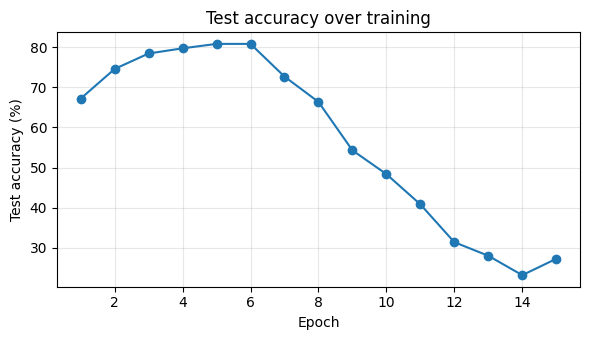

In [7]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(range(1, N_EPOCHS + 1), [a * 100 for a in history["test_acc"]], "o-")
ax.set_xlabel("Epoch")
ax.set_ylabel("Test accuracy (%)")
ax.set_title("Test accuracy over training")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### Energy convergence

Shows the **total latent energy** (internal consistency + CE readout)
during inference on the first batch of selected epochs.
Decreasing energy confirms the inference loop is working correctly.

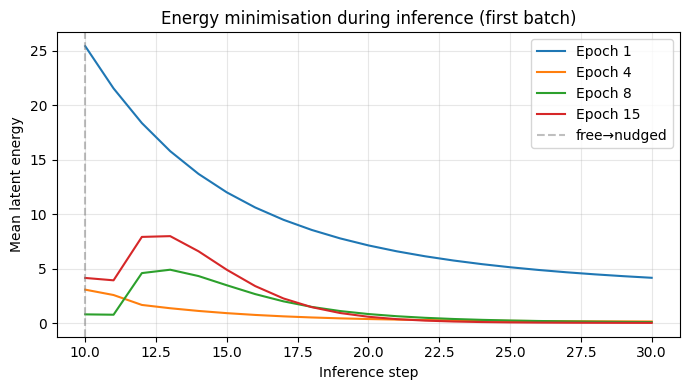

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
# Plot a selection of epochs: first, middle, last
epochs_to_show = [0, N_EPOCHS // 4, N_EPOCHS // 2, N_EPOCHS - 1]
epochs_to_show = sorted(set(min(e, N_EPOCHS - 1) for e in epochs_to_show))
for e in epochs_to_show:
    ax.plot(range(10, len(history["diag"][e]["energy"]) + 1), history["diag"][e]["energy"][9:], label=f"Epoch {e+1}")
ax.set_xlabel("Inference step")
ax.set_ylabel("Mean latent energy")
ax.set_title("Energy minimisation during inference (first batch)")
if USE_EQPROP:
    ax.axvline(T_FREE, color="gray", ls="--", alpha=0.5, label="free→nudged")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### Fixed-point distance

The **free energy** measures internal consistency: how close the latents
are to a fixed point of the implicit cycle (z* = f(z*)).
A value approaching zero means the network has converged.

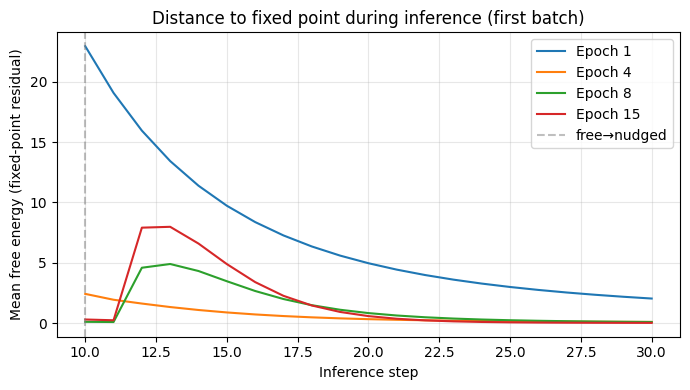

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
for e in epochs_to_show:
    ax.plot(range(10, len(history["diag"][e]["fp_dist"]) + 1), history["diag"][e]["fp_dist"][9:], label=f"Epoch {e+1}")
ax.set_xlabel("Inference step")
ax.set_ylabel("Mean free energy (fixed-point residual)")
ax.set_title("Distance to fixed point during inference (first batch)")
if USE_EQPROP:
    ax.axvline(T_FREE, color="gray", ls="--", alpha=0.5, label="free→nudged")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### Weight norms

Tracks the Frobenius norm of each weight matrix across epochs.
The implicit-block weights (f1, f2) are the most important to monitor:
if they grow too large, the fixed-point iteration may diverge.
Spectral projection keeps them bounded.

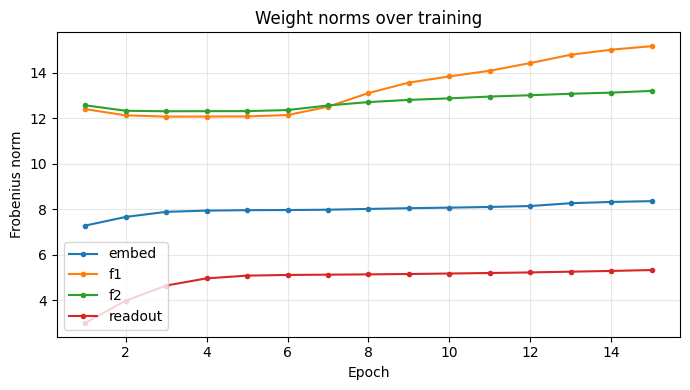

In [10]:
wn = history["weight_norms"]
fig, ax = plt.subplots(figsize=(7, 4))
for key in wn[0]:
    ax.plot(range(1, N_EPOCHS + 1), [w[key] for w in wn], "o-", ms=3, label=key)
ax.set_xlabel("Epoch")
ax.set_ylabel("Frobenius norm")
ax.set_title("Weight norms over training")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

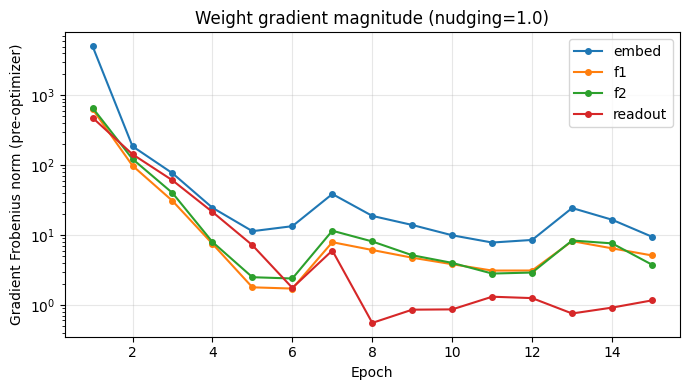

In [11]:
# This directly tests the hypothesis: weight gradients ∝ nudging.
# If gradient norms collapse after epoch 1, the model has converged its
# inference loop too well — prediction errors (which drive weight learning)
# have shrunk to O(nudging). Compare across different nudging values.

# %% Plot 5: Weight gradient norms
gn = history["grad_norms"]
fig, ax = plt.subplots(figsize=(7, 4))
for key in gn[0]:
    vals = [g[key] for g in gn]
    ax.plot(range(1, N_EPOCHS + 1), vals, "o-", ms=4, label=key)
ax.set_xlabel("Epoch")
ax.set_ylabel("Gradient Frobenius norm (pre-optimizer)")
ax.set_title(f"Weight gradient magnitude (nudging={NUDGING})")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

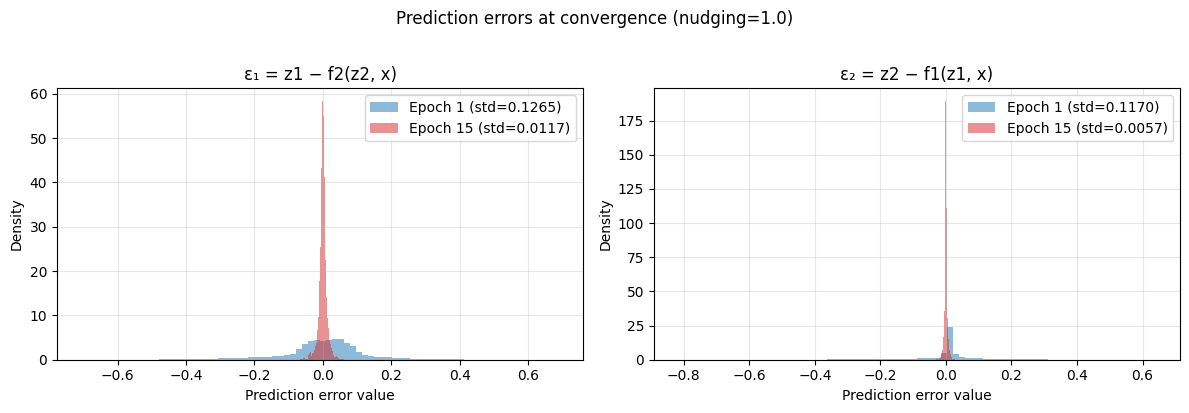

Epoch 1: ||ε₁||_rms = 0.12650, ||ε₂||_rms = 0.11696
Epoch 15: ||ε₁||_rms = 0.01168, ||ε₂||_rms = 0.00575


In [12]:
# %% [markdown]
# ### Prediction errors at convergence
#
# Histograms of ε₁ = z1 − f2(z2, x) and ε₂ = z2 − f1(z1, x) at the end
# of inference, across all samples in the diagnostic batch.
#
# These are the signals that drive weight learning in PC. If they cluster
# tightly around zero, the weight gradients are tiny and learning stalls.
# The spread should be ≈ O(nudging). Comparing epoch 1 vs last epoch
# shows whether errors shrink as inference improves.

# %% Plot 6: Prediction error histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_to_compare = [0, N_EPOCHS - 1]
colors = ["tab:blue", "tab:red"]

for ax, (eps_key, title) in zip(axes, [
    ("eps1", "ε₁ = z1 − f2(z2, x)"),
    ("eps2", "ε₂ = z2 − f1(z1, x)"),
]):
    for e, c in zip(epochs_to_compare, colors):
        eps = history["diag"][e][eps_key].flatten()
        ax.hist(eps, bins=80, alpha=0.5, color=c, density=True,
                label=f"Epoch {e+1} (std={eps.std():.4f})")
    ax.set_xlabel("Prediction error value")
    ax.set_ylabel("Density")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Prediction errors at convergence (nudging={NUDGING})", y=1.02)
fig.tight_layout()
plt.show()

# Print summary stats
for e in epochs_to_compare:
    eps1_std = history["diag"][e]["eps1"].std()
    eps2_std = history["diag"][e]["eps2"].std()
    print(f"Epoch {e+1}: ||ε₁||_rms = {eps1_std:.5f}, "
          f"||ε₂||_rms = {eps2_std:.5f}")

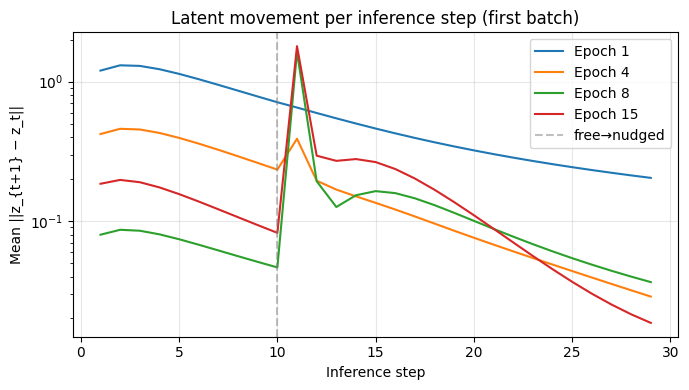

In [13]:
# %% [markdown]
# ### Latent step size (inference convergence)
#
# Shows ||z_{t+1} − z_t|| at each inference step — how much the latents
# move per iteration. This reveals:
# - **Convergence rate**: how quickly the system reaches equilibrium
# - **Wasted compute**: if step size → 0 long before T_STEPS, later
#   iterations do nothing (could use fewer steps)
# - **Oscillation**: if step size bounces around, LR_H is too high
# - **EP phase transition**: in EP mode, the nudged phase should show
#   a bump as the label signal perturbs the free equilibrium

# %% Plot 7: Latent step size
fig, ax = plt.subplots(figsize=(7, 4))
epochs_to_show = [0, N_EPOCHS // 4, N_EPOCHS // 2, N_EPOCHS - 1]
epochs_to_show = sorted(set(min(e, N_EPOCHS - 1) for e in epochs_to_show))
for e in epochs_to_show:
    steps = history["diag"][e]["latent_step"]
    ax.plot(range(1, len(steps) + 1), steps, label=f"Epoch {e+1}")
ax.set_xlabel("Inference step")
ax.set_ylabel("Mean ||z_{t+1} − z_t||")
ax.set_title("Latent movement per inference step (first batch)")
ax.set_yscale("log")
if USE_EQPROP:
    ax.axvline(T_FREE, color="gray", ls="--", alpha=0.5, label="free→nudged")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()